# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [ ]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [ ]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [ ]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


El dataset no presenta valores ausentes. La columna `landing` define los grupos en tipo binario (A/B) al igual que `converted`(0/1).

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


**Variable `user_id`**  
Verificar usuarios únicos

In [ ]:
df['user_id'].nunique()

40000

No hay valores repetidos en `user_id`.

 **Variable `date`**  
Explorar rango de fechas

In [ ]:
# Resumen estadístico
df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [ ]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [ ]:
# Resumen estadístico
df['gasto'].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [ ]:
# Resumen estadístico de usuarios que se convirtieron
df[df['converted'] == 1]['gasto'].describe()

count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [ ]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías y distribución:")
print('\n')
columnas_cat = ['user_type','landing', 'region', 'dispositivo', 'traffic_source']
print()
for columna in columnas_cat:
    print(f'Columna: {columna}')
    print(df[columna].value_counts(normalize=True) * 100)
    
    print('\n')



Conteo de categorías y distribución:



Columna: user_type
Nuevo         65.0825
Recurrente    34.9175
Name: user_type, dtype: float64


Columna: landing
B    50.045
A    49.955
Name: landing, dtype: float64


Columna: region
Norte        27.9150
Centro       24.0325
Sur          20.0975
Occidente    15.9950
Oriente      11.9600
Name: region, dtype: float64


Columna: dispositivo
Mobile     62.0725
Desktop    37.9275
Name: dispositivo, dtype: float64


Columna: traffic_source
Organic     44.9675
Ads         29.8375
Email       15.3075
Referral     9.8875
Name: traffic_source, dtype: float64




Las columnas categoricas tienen valores esperados. `landing` muestra una distribucion similar entre ambos experimentos. 

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [ ]:
# Gasto por versión
gasto_A = df[(df['landing'] == 'A') & (df['converted'] == 1)]
gasto_B = df[(df['landing'] == 'B') & (df['converted'] == 1)]

print('Gasto promedio usuario en página A: ', round(gasto_A['gasto'].mean(), 2))
print('Gasto promedio usuario en página B: ', round(gasto_B['gasto'].mean(), 2))

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

Gasto promedio usuario en página A:  61.09
Gasto promedio usuario en página B:  68.75


(2512, 3194)

### Prueba Mannwhitneyu
**Hipótesis:**
- **Hipótesis nula (H₀):** Es igual o minima la diferencia del gasto promedio del usuario que se convirtió a cliente entre ambas versiones de las páginas.
- **Hipótesis alternativa (H₁):** Existe una diferencia significativa en el gasto promedio del usuario convertido a cliente entre ambas versiones de las páginas.

In [ ]:
# Aplicar prueba
from scipy.stats import mannwhitneyu, ttest_ind, levene

stat, p_value = mannwhitneyu(gasto_A['gasto'], gasto_B['gasto'])
stat_t, p_ttest = ttest_ind(gasto_A['gasto'], gasto_B['gasto'], equal_var=False)
stat_levene, p_levene = levene(gasto_A['gasto'], gasto_B['gasto'])

# Visualizar resultados
print(f"Estadístico : {stat}")
print(f"Valor p: {p_value:}")
print(f"T-test p-value: {p_ttest}")
print(f"Levene p-value: {p_levene}")

Estadístico : 3420354.0
Valor p: 1.0437550649433317e-21
T-test p-value: 3.627602231521493e-21
Levene p-value: 6.875301988016449e-08


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula.

**Interpretación de negocio:**  

La prueba estadística de Levene arrojó un valor p de 6.88 × 10e-08, muy por debajo del umbral de significancia de 0.05, lo que permite rechazar la variable `equal_var` y con ello la hipótesis nula para evitar un resultado sesgado ya que las varianzas no son iguales. Con base a esto, se aplico la prueba t-test e indicó tambien un p-value por debajo del umbral de 0.05 el cual fue de 3.63 x 10e-21.

Esto confirma que la diferencia observada en el gasto promedio entre los usuarios convertidos de ambas versiones de la página es estadísticamente significativa y no se debe al azar.

Los usuarios convertidos en la página A gastaron en promedio 61.09 unidades monetarias, frente a 68.75 unidades en la página B, lo que representa un incremento de 7.66 unidades (aproximadamente 12.5 %). Dado que la diferencia es tanto significativa estadísticamente como relevante en términos prácticos, se recomienda analizar mas a fondo la versión B, ya que genera un mayor valor por usuario convertido y podría traducirse en un aumento sustancial de los ingresos totales al escalar la implementación.

---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba Z-Test

**Hipótesis:**
- **Hipótesis nula (H₀):** Es igual o similar la tasa de conversión entre las páginas A y B de usuarios.
- **Hipótesis alternativa (H₁):** Existe una diferencia significativa en la tasa de conversión entre las páginas A y B de usuarios.

In [ ]:
# Número de usuarios convertidos por página
usuarios_A = df[(df['landing'] == 'A') & (df['converted'] == 1)]
usuarios_B = df[(df['landing'] == 'B') & (df['converted'] == 1)]

# Total de usuarios por página
total_A = df[(df['landing'] == 'A')]
total_B = df[(df['landing'] == 'B')]

print("Usuarios convertidos:\n",'Pagina A:', len(usuarios_A),'Pagina B:', len(usuarios_B))

print("\nTotal de usuarios:\n",'Pagina A:', len(total_A),'Pagina B:', len(total_B))


Usuarios convertidos:
 Pagina A: 2512 Pagina B: 3194

Total de usuarios:
 Pagina A: 19982 Pagina B: 20018


In [ ]:
from statsmodels.stats.proportion import proportions_ztest

In [ ]:
# Aplicar prueba
count_list = [len(usuarios_A), len(usuarios_B)]
nobs_list = [len(total_A), len(total_B)]

stat, p_value = proportions_ztest(count_list, nobs_list)

tasa_A = len(usuarios_A) / len(total_A) * 100
tasa_B = len(usuarios_B) / len(total_B) * 100

# Visualizar resultados
print(f'Tasa de Conversión A : {tasa_A:.2f}%')
print(f'Tasa de Conversión B : {tasa_B:.2f}%')
print(f"Estadístico : {stat}")
print(f"Valor p: {p_value}")

Tasa de Conversión A : 12.57%
Tasa de Conversión B : 15.96%
Estadístico : -9.677362674655983
Valor p: 3.7629765627523803e-22


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula.

**Interpretación de negocio:**  

La prueba estadística arrojó un valor p de 3.76 × 10e-22, muy por debajo del umbral de significancia de 0.05, lo que permite rechazar la hipótesis nula con un nivel de confianza superior al 99.99 %. Esto confirma que la diferencia observada en la tasa de conversión de usuarios en ambas versiones de la página es estadísticamente significativa y no se debe al azar.

La tasa de conversión de la versión B (15.96 %) supera a la de la versión A (12.57 %), lo que representa un incremento de 3.39 puntos porcentuales. Dado que la diferencia es tanto estadísticamente significativa como relevante en términos prácticos, se recomienda analizar más a fondo la versión B, ya que no solo genera una mayor tasa de conversión, sino que también se asocia con un incremento en el gasto por usuario.


## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba Chi-cuadrado

**Hipótesis:**
- **Hipótesis nula (H₀):** La relación entre la fuente de tráfico del usuario y su conversión a cliente no es estadisticamente significativa.
- **Hipótesis alternativa (H₁):** La relación entre la fuente de tráfico del usuario y su conversión a cliente es estadisticamente significativa.

In [ ]:
from scipy.stats import chi2_contingency

In [ ]:
# Aplicar prueba
tabla = pd.crosstab(df['traffic_source'], df['converted'])
chi2, p, dof, expected = chi2_contingency(tabla)
chi2_contingency(tabla)

Chi2ContingencyResult(statistic=8.662108841397938, pvalue=0.0341375947833914, dof=3, expected_freq=array([[10232.47225,  1702.52775],
       [ 5249.55405,   873.44595],
       [15421.15445,  2565.84555],
       [ 3390.81925,   564.18075]]))

In [ ]:
df.groupby('traffic_source')['converted'].mean().sort_values(ascending=False) * 100

traffic_source
Email       14.992651
Ads         14.738165
Referral    13.881163
Organic     13.787736
Name: converted, dtype: float64

### 📝 Conclusión e interpretación


**Decisión:**  
Se rechaza la hipótesis nula. 

**Interpretación de negocio:**  

La prueba estadística arrojó un valor p de 0.034, el cual esta debajo del umbral de significancia de 0.05, lo que permite rechazar la hipótesis nula con un nivel de confianza superior al 96 %. Esto confirma que hay una relación significativa entre el usuario convertido a cliente y su fuente de tráfico.
De acuerdo a la exploración de datos, los canales con mejor promedio de conversión son por via `Email`(14.99%) y `Ads`(14.74%) por lo que se recomienda darle un enfoque profundo a este tipo de canales. Además, es importante recalcar que el porcentaje de tráfico mas alto lo tiene el canal `Organic` pero tiene la tasa de conversión mas baja de todos los canales contrario a `Email` que si éste mejorara su tráfico, aumentaría significativamente sus resultados de conversión.

## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba Chi-Cuadrado de contingencia

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe una asociación estadísticamente significativa entre `user_type` y `converted`.
- **Hipótesis alternativa (H₁):** Existe una asociación estadísticamente significativa entre `user_type` y `converted`.

In [ ]:
# Distribución de `user_type`
df.groupby('user_type')['converted'].mean().sort_values(ascending=False) * 100

user_type
Nuevo         14.358699
Recurrente    14.090356
Name: converted, dtype: float64

In [ ]:
# Aplicar prueba
tabla = pd.crosstab(df['user_type'], df['converted'])
chi2, p, dof, expected = chi2_contingency(tabla)
chi2_contingency(tabla)


Chi2ContingencyResult(statistic=0.5134849494478645, pvalue=0.4736341272301974, dof=1, expected_freq=array([[22319.39255,  3713.60745],
       [11974.60745,  1992.39255]]))

### 📝 Conclusión e interpretación

**Decisión:**  
No se rechaza la hipotesis nula. 

**Interpretación de negocio:**  
Con un resultado p-value de 0.47, podemos entender que no hay una asociación significativa entre `user_type` y `converted` ya que esta muy por encima del umbral (α = 0.05). Es decir, que el tipo de usuario no influye significativamente en la conversión a cliente del mismo. Esto es asi teniendo en cuenta tambien que la tasa de conversion de usuarios "Nuevo" y "Recurrente" son muy similares (14.36% y 14.09% respectivamente). Dicho esto, se recomienda enfocar la inversión en los canales de `Email` y `Ads` por las razones mencionadas anteriormente.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

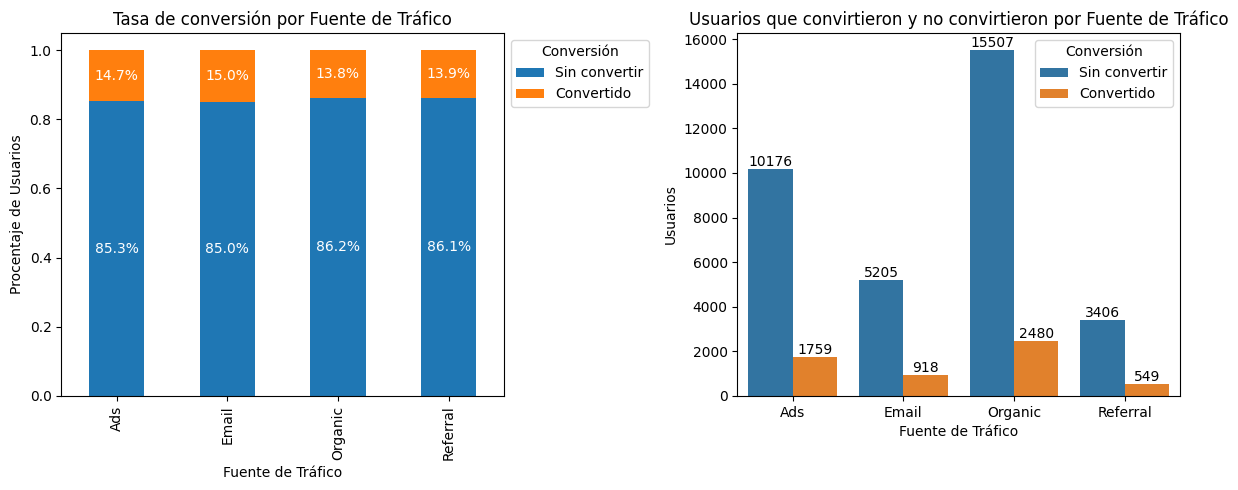

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

tabla_prop1 = pd.crosstab(df['traffic_source'], df['converted'], normalize='index')
tabla_prop1.plot(kind='bar', stacked=True, ax=ax1)
for container in ax1.containers:
    for bar in container:
        height = bar.get_height()
        x = bar.get_x() + bar.get_width() / 2
        y = bar.get_y() + height / 2  
        if height > 0.01:  # evitar etiquetar segmentos muy pequeños
            ax1.text(x, y, f'{height*100:.1f}%', ha='center', va='center', color='white')
ax1.legend(loc='upper left', bbox_to_anchor=(1, 1),title='Conversión', labels=['Sin convertir', 'Convertido'])
ax1.set_title("Tasa de conversión por Fuente de Tráfico")
ax1.set_xlabel("Fuente de Tráfico")
ax1.set_ylabel('Procentaje de Usuarios')

sns.countplot(data=df, x='traffic_source', hue='converted', ax=ax2, order=['Ads','Email','Organic','Referral'])
for p in ax2.patches:
    ax2.annotate(str(int(p.get_height())), 
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom')
ax2.set_title("Usuarios que convirtieron y no convirtieron por Fuente de Tráfico")
ax2.legend(title='Conversión', labels=['Sin convertir', 'Convertido'])
ax2.set_xlabel("Fuente de Tráfico")
ax2.set_ylabel('Usuarios')
plt.tight_layout()
plt.show()

El gráfico de barras apiladas muestra que todos los canales tienen proporciones de conversión similares, entre el 14% y el 15% aproximadamente, con Email ligeramente adelante con un 15.0% y Orgánico detrás con un 13.8%. Un valor p de 0.034 confirma que esta pequeña diferencia es estadísticamente significativa, lo que significa que es poco probable que se deba al azar, aunque sea modesta en términos prácticos.

El gráfico de conteo revela una imagen muy diferente en cuanto a volumen. La búsqueda orgánica domina con casi el 45% del tráfico total, mientras que Email representa solo alrededor del 15%. Esto crea una desconexión notable: el canal con más usuarios tiene una de las tasas de conversiónes más baja, y el canal con menos usuarios tiene la más alta.

La conclusión clave es la paradoja del volumen: más tráfico no se traduce automáticamente en más conversiones. Email es el canal más eficiente: logra la tasa de conversión más alta con la audiencia más pequeña, mientras que Orgánico rinde por debajo de lo esperado a pesar de ser la mayor fuente de visitantes. Desde una perspectiva de toma de decisiones, esto sugiere que seguir invirtiendo en la optimización o personalización del Email podría generar buenos retornos, mientras que simplemente aumentar el tráfico Orgánico sin mejorar su tasa de conversión podría ser menos efectivo.

### Relación entre el tipo de usuario y la conversión

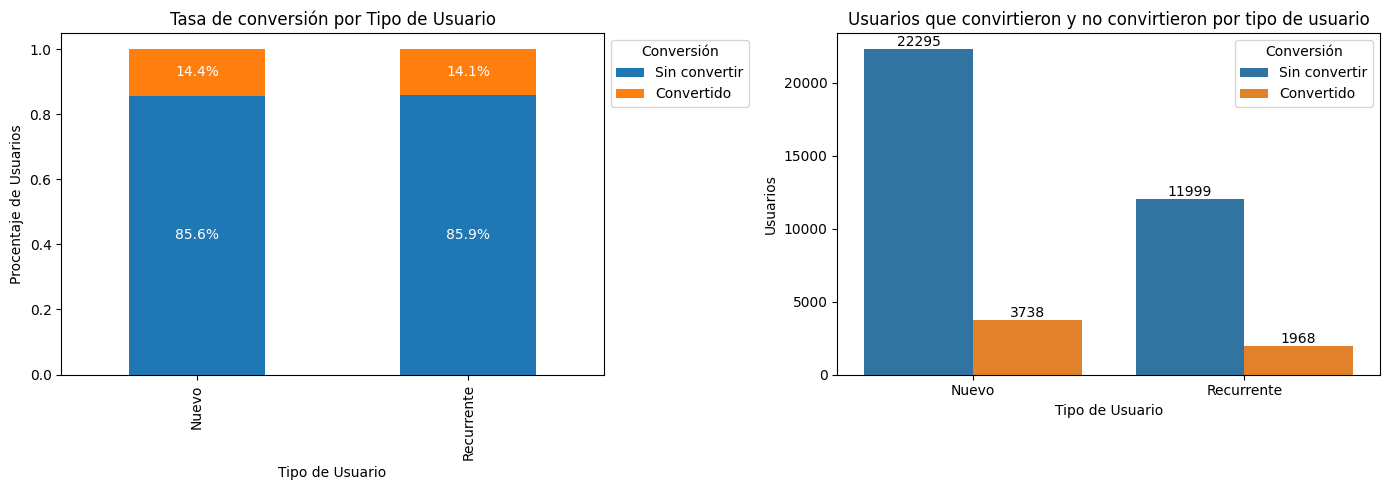

In [ ]:
from matplotlib.ticker import FuncFormatter
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

tabla_prop1 = pd.crosstab(df['user_type'], df['converted'], normalize='index')
tabla_prop1.plot(kind='bar', stacked=True, ax=ax1)
for container in ax1.containers:
    for bar in container:
        height = bar.get_height()
        x = bar.get_x() + bar.get_width() / 2
        y = bar.get_y() + height / 2  
        if height > 0.01:  # evitar etiquetar segmentos muy pequeños
            ax1.text(x, y, f'{height*100:.1f}%', ha='center', va='center', color='white')
ax1.legend(loc='upper left', bbox_to_anchor=(1, 1),title='Conversión', labels=['Sin convertir', 'Convertido'])
ax1.set_title("Tasa de conversión por Tipo de Usuario")
ax1.set_xlabel("Tipo de Usuario")
ax1.set_ylabel('Procentaje de Usuarios')

sns.countplot(data=df, x='user_type', hue='converted', ax=ax2, order=['Nuevo','Recurrente'])
for p in ax2.patches:
    ax2.annotate(str(int(p.get_height())), 
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom')
ax2.set_title("Usuarios que convirtieron y no convirtieron por tipo de usuario")
ax2.legend(title='Conversión', labels=['Sin convertir', 'Convertido'])
ax2.set_xlabel("Tipo de Usuario")
ax2.set_ylabel('Usuarios')
plt.tight_layout()
plt.show()


El primer gráfico muestra una similitud en la proporción de conversión dentro de cada grupo: un 14.4% de los usuarios nuevos convirtió frente a un 14.1% de los recurrentes. Esto indica que el tipo de usuario no influye prácticamente en la probabilidad de convertir. El segundo gráfico, muestra el volumen absoluto de usuarios en cada categoría. Aquí se observa que hay muchos más usuarios nuevos que recurrentes. Sin embargo, a pesar de esta diferencia en tamaño de grupo, la tasa de conversión se mantiene prácticamente igual entre ambos, reforzando la idea de que el tipo de usuario no es un factor determinante.

Estos hallazgos visuales se conectan directamente con el análisis estadístico previamente realizado. La prueba Chi-cuadrado arrojó un p-value de 0.47, muy por encima del umbral de significancia de 0.05. Esto confirma que la mínima diferencia observada entre el 14.4% y el 14.1% no es estadísticamente significativa y bien podría deberse al azar.

En conjunto, tanto los gráficos como la prueba estadística convergen en la misma conclusión: no existe evidencia suficiente para afirmar que el tipo de usuario (nuevo o recurrente) tenga un impacto real en la tasa de conversión. Las diferencias observadas son residuales y no permiten rechazar la hipótesis de independencia entre ambas variables.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

**Para la toma de decisiones**

`La página B es la nueva estándar`
La versión B supera a la A en las dos métricas que importan: tasa de conversión (15.96 % vs. 12.57 %, +27 % relativo) y gasto promedio por cliente (68.75 u.m. vs. 61.09 u.m., +12.5 %). El impacto conjunto es un incremento estimado del +43 % en ingresos totales. No hay incertidumbre estadística relevante — ambos resultados tienen p-valores extremadamente bajos. Recomendación: implementar la página B como landing page única y definitiva.

`Los canales de tráfico tienen rendimientos dispares`
El canal Email es el más eficiente (15.0 % de conversión) pero está subexplotado (solo el 15 % del tráfico). El canal Orgánico representa el 45 % de las visitas pero tiene la tasa más baja (13.8 %), lo que sugiere un desajuste entre lo que los usuarios buscan y lo que ofrece la página. Ads se mantiene como un canal sólido (14.7 % con buen volumen). Recomendación: aumentar presupuesto en Email, auditar la estrategia SEO, y mantener Ads con optimización continua.

`El tipo de usuario no es un factor relevante`
Usuarios nuevos y recurrentes convierten prácticamente igual (~14 %), sin diferencias estadísticas. Esto simplifica la estrategia: no se necesita segmentar campañas por tipo de usuario, lo que libera recursos para enfocarse en canales y en la optimización de la página.

**En una frase:** Implementar la página B, redirigir inversión hacia Email Marketing y auditar el tráfico orgánico produce el mayor retorno con la menor complejidad operativa.

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**

- La página B registra un gasto promedio de 68.75 u.m. frente a 61.09 u.m. de la página A, una diferencia de +7.66 u.m. por cliente.
- La prueba estadística de Levene arrojó un valor p de 6.88 × 10e-08, muy por debajo del umbral de significancia de 0.05. Con base a esto, se aplico la prueba t-test e indicó tambien un p-value por debajo del umbral de 0.05 confirmando que la diferencia observada en el gasto promedio entre los usuarios convertidos de ambas versiones de la página es estadísticamente significativa y no se debe al azar.
  
**Interpretación:** La página B no solo atrae a más compradores, sino que cada comprador gasta un 12.5 % más. Esto representa una ganancia directa en ingresos por cliente que se multiplica con el volumen de conversiones.

**Tasa de conversión:**

- La página B convierte al 15.96 %, mientras que la página A lo hace al 12.57 %, un incremento de 3.39 puntos porcentuales (+27 % relativo).
- El z-test de proporciones arrojó un p-value de 3.76 × 10⁻²², confirmando significancia estadística contundente.

**Interpretación:** En los 20,018 usuarios expuestos a la versión B, se generaron 682 conversiones adicionales frente a la versión A. El efecto combinado de mayor conversión y mayor gasto promedio se traduce en un incremento del +43 % en ingresos totales estimados.

---

#### 📊 **Segmentación por fuente de tráfico**

**Tasas de conversión por canal:**
- Email (15.0 %), Ads (14.7 %), Referral (13.9 %), Organic (13.8 %).
- La prueba chi-cuadrado arrojó un p-value de 0.034, indicando que el canal de tráfico sí influye en la probabilidad de conversión.

**Interpretación:** El canal Email es el más eficiente pero solo representa el 15.3 % del tráfico total; está infraexplotado. El canal Organic genera el 45 % del tráfico pero tiene la conversión más baja, lo que sugiere un desajuste entre la intención de búsqueda del usuario y la propuesta de valor de la landing page. Ads es un canal sólido con buen balance entre volumen y conversión.

#### 📊 **Segmentación por tipo de usuario**

**Tasas de conversión:** 
- Usuarios nuevos (14.36 %) vs. recurrentes (14.09 %).
- La prueba chi-cuadrado arrojó un p-value de 0.47, indicando que no existe diferencia estadísticamente significativa entre ambos grupos.

**Interpretación:** El historial del usuario (nuevo vs. recurrente) no impacta la decisión de compra en esta landing page. Ambos segmentos responden de forma equivalente a la misma versión de página, lo que simplifica la estrategia de marketing al no requerir segmentación específica por tipo de usuario.

---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:** 

- Implementar la página B como landing page definitiva de inmediato. Es superior en conversión (+27 %) y gasto promedio (+12.5 %), con un impacto estimado de +43 % en ingresos totales. No hay incertidumbre estadística que justifique retrasar la decisión.
  
- Redistribuir la inversión en canales de tráfico: aumentar presupuesto en Email Marketing (el canal más eficiente), auditar la estrategia SEO para alinear el tráfico orgánico con la propuesta de valor, y mantener Ads con optimización continua en segmentación y creatividades. No segmentar campañas por tipo de usuario, ya que no se encontraron diferencias relevantes entre nuevos y recurrentes.

- Optimizar las campañas de Ads mediante pruebas A/B en segmentación y creatividades, y escalar el canal Referral a través de un programa de referidos.

- El tipo de usuario no es un factor relevante. Esto simplifica la estrategia: no se necesita segmentar campañas por tipo de usuario, lo que libera recursos para enfocarse en canales y en la optimización de la página.

- Monitorear los resultados 30 días después de implementar la página B y continuar con pruebas A/B iterativas sobre elementos específicos (titulares, CTAs, imágenes) para seguir mejorando el rendimiento.